<a href="https://colab.research.google.com/github/Sahil-K-Y/AI-ML-Blueprint/blob/main/Phase-6%20-%20Deep%20Learning%20%26%20PyTorch/088_adam_adamw_math.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 088: Adaptive Optimizers (Adagrad → RMSprop → Adam → AdamW)

**Today's goal:** Understand how each parameter gets its own *individual* learning rate, and exactly how Adam / AdamW work under the hood. Everything is implemented in **pure NumPy** (preceding PyTorch Day 095).

| # | Concept | In one line |
|---|---|---|
| 1 | **Adagrad** | Each parameter has a diary; the more frequent the updates, the smaller the step |
| 2 | **RMSprop** | A diary that gradually forgets older history (fixing Adagrad's flaw) |
| 3 | **Adam** | Momentum (remembering direction) + RMSprop (remembering scale/magnitude) |
| 4 | **Bias correction** | Adjusting initial estimates to fix the cold-start bias |
| 5 | **AdamW** | Decoupling weight decay from the adaptive gradient steps |

**How to study this:** Go top to bottom, one cell at a time. Read the markdown first, then run the code, and match the output with the explanations provided.

## 📖 Symbols Dictionary (Keep coming back here for reference)

| Symbol | Meaning | Code Representation |
|---|---|---|
| θ (theta) | Parameter / weight being updated | `theta` |
| g | Gradient = slope (direction of steepest ascent) | `g` |
| η (eta) | Learning rate = base step size | `lr` |
| g² | Squared gradient. For arrays, this is the **element-wise square** | `g**2` |
| √ | Square root (element-wise) | `np.sqrt(...)` |
| ε (epsilon) | A very small number (1e-8) to prevent division by zero | `eps` |
| t | Time step / iteration number (1, 2, 3, ...) | `t` |
| β (beta) | "How much past history to remember", between 0 and 1. (0.9 means roughly the last 10 steps) | `beta` |
| λ (lambda) | Weight decay coefficient | `wd` |

> **Key takeaway:** Every operation here is done **independently per-parameter**. If your model has 1 million weights, there are 1 million individual values for `G` (or `m`, `v`).

In [7]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

## 0️⃣ What is the core problem? (Recap)

In Plain Gradient Descent (Day 002) and Momentum (Day 087), the update step is:

```
θ = θ − η · g
```

Here, the learning rate `η` is **the same for all parameters**. However, different parameters can have gradients of completely different scales:

| Parameter | Gradient | Step size with same η = 0.1 | Problem |
|---|---|---|---|
| w₁ | 10 (steep) | 1.0 | Overshoots because the step is too large |
| w₂ | 1 (flat) | 0.1 | Extremely slow progress because the step is too small |

**The Adaptive Optimizer Solution:** Adjust the step size for each parameter **individually** based on its unique historical gradients.

### Our test problem: A long, narrow valley (elongated bowl)

$$f(x, y) = 5x^2 + 0.5y^2 \	 qback 	 g = [\,10x,\; y\,]$$

- **x direction:** highly steep (gradient 10x)
- **y direction:** extremely flat (gradient y)

This is a classic scenario where using a single fixed `η` fails to optimize both parameters efficiently.

In [24]:
def loss_fn(theta):
    return 5 * theta[0]**2 + 0.5 * theta[1]**2

def grad_fn(theta):
    return np.array([10 * theta[0], theta[1]])

# Baseline: plain gradient descent (no adaptive mechanism)
def sgd(grad_fn, theta0, lr=0.05, steps=100):
    theta = theta0.astype(float).copy()
    history = [theta.copy()]
    for _ in range(steps):
        g = grad_fn(theta)
        theta = theta - lr * g                 # same lr for all parameters
        history.append(theta.copy())
    return np.array(history)

theta0 = np.array([-1.0, 1.0])                 # start point
h = sgd(grad_fn, theta0, lr=0.05, steps=100)
print("Start        :", theta0, " loss =", loss_fn(theta0))
print("After 20 steps:", h[20], " loss =", round(loss_fn(h[20]), 4))
print("\nObserve: x becomes ~0 in just 20 steps, but y is still around 0.36.")
print("Since the gradient for y was small, its step was also small. The same lr is used for both directions.")

Start        : [-1.  1.]  loss = 5.5
After 20 steps: [-0.      0.3585]  loss = 0.0643

Observe: x becomes ~0 in just 20 steps, but y is still around 0.36.
Since the gradient for y was small, its step was also small. The same lr is used for both directions.


## 1️⃣ Adagrad

### In one line
> Each parameter maintains a **history diary `G`** that accumulates the *squares* of its gradients. The larger this history grows, the smaller the update step becomes for that parameter.

### Formula (all operations are element-wise)

| Step | Formula | Meaning |
|---|---|---|
| 1. Accumulate history | `G = G + g²` | Sum of squared gradients up to current step |
| 2. Parameter Update | `θ = θ − η · g / (√G + ε)` | Normalize the step by dividing by `√G` |

Think of `η / √G` as an **effective learning rate** adjusted individually for each parameter.

### Worked Example: Large vs. Small Gradients
Let's trace two parameters with η = 0.1 and constant gradients:
- w₁: g = 4 (large gradient)
- w₂: g = 0.1 (small gradient)

The code below runs this step-by-step. **Notice:** Adagrad dynamically rescales both steps to be *equal*, whereas in plain GD, the step for w₁ would be 40 times larger than w₂.

In [25]:
lr = 0.1
for name, g in [("w1 (large gradient, g=4)", 4.0), ("w2 (small gradient, g=0.1)", 0.1)]:
    G = 0.0                                    # start with an empty history diary
    print(name)
    for t in range(1, 4):
        G = G + g**2                           # accumulate g² into the diary
        adagrad_step = lr * g / np.sqrt(G)     # Adagrad step
        plain_step   = lr * g                  # normal GD step
        print(f"  t={t}  G={G:7.3f}  sqrt(G)={np.sqrt(G):6.4f}  "
              f"Adagrad step={adagrad_step:.4f}   plain GD step={plain_step:.4f}")
    print()

w1 (large gradient, g=4)
  t=1  G= 16.000  sqrt(G)=4.0000  Adagrad step=0.1000   plain GD step=0.4000
  t=2  G= 32.000  sqrt(G)=5.6569  Adagrad step=0.0707   plain GD step=0.4000
  t=3  G= 48.000  sqrt(G)=6.9282  Adagrad step=0.0577   plain GD step=0.4000

w2 (small gradient, g=0.1)
  t=1  G=  0.010  sqrt(G)=0.1000  Adagrad step=0.1000   plain GD step=0.0100
  t=2  G=  0.020  sqrt(G)=0.1414  Adagrad step=0.0707   plain GD step=0.0100
  t=3  G=  0.030  sqrt(G)=0.1732  Adagrad step=0.0577   plain GD step=0.0100



### What did we observe?

| | w₁ (g=4) | w₂ (g=0.1) |
|---|---|---|
| Plain GD step | 0.4 | 0.01 (40× smaller!) |
| Adagrad step (t=1) | 0.1 | 0.1 (**identical**) |

1. **Scale Normalization:** Regardless of the gradient's original scale, Adagrad equalizes the step sizes. This demonstrates adaptive behavior.
2. **Decaying Steps:** The step sizes continuously shrink over time (0.1 → 0.0707 → 0.0577, decaying roughly at a rate of `η/√t`).

### ⚠️ The Limitation of Adagrad
The history `G` **only increases and never decreases**. This causes the effective learning rate `η/√G` to continuously decline to zero. Let's see what happens even with a constant gradient (g = 1) over a longer run:

In [26]:
G, g, lr = 0.0, 1.0, 0.1
for t in range(1, 1001):
    G += g**2
    if t in (1, 10, 100, 1000):
        print(f"t={t:5d}  effective lr = lr/sqrt(G) = {lr/np.sqrt(G):.5f}")
print("\nIn long training, the LR drops close to 0 -> the model stops learning.")

t=    1  effective lr = lr/sqrt(G) = 0.10000
t=   10  effective lr = lr/sqrt(G) = 0.03162
t=  100  effective lr = lr/sqrt(G) = 0.01000
t= 1000  effective lr = lr/sqrt(G) = 0.00316

In long training, the LR drops close to 0 -> the model stops learning.


In [27]:
def adagrad(grad_fn, theta0, lr=0.5, steps=100, eps=1e-8):
    theta = theta0.astype(float).copy()
    G = np.zeros_like(theta)                       # each parameter has its own diary
    history = [theta.copy()]
    for _ in range(steps):
        g = grad_fn(theta)
        G += g**2                                  # diary only accumulates and grows
        theta = theta - lr * g / (np.sqrt(G) + eps)
        history.append(theta.copy())
    return np.array(history)

h_ada = adagrad(grad_fn, theta0, lr=0.5, steps=100)
print("Adagrad end:", h_ada[-1], " loss =", loss_fn(h_ada[-1]))

Adagrad end: [-0.  0.]  loss = 1.0250306362104689e-48


## 2️⃣ RMSprop (Fixing Adagrad's Limitation)

### In one line
> Instead of accumulating gradients infinitely, maintain an **exponential moving average** that progressively discounts older gradient histories.

### Formula

| Step | Adagrad | RMSprop |
|---|---|---|
| History Tracking | `G = G + g²` | `E = β·E + (1−β)·g²` |
| Parameter Update | `θ = θ − η·g/(√G+ε)` | `θ = θ − η·g/(√E+ε)` |

- `β` (typically **0.9**) controls how much past history to retain.
- `E` does **not grow infinitely**. It stabilizes around the magnitude of recent squared gradients, preventing the effective learning rate from dying out.

### Worked Example (g = 4 constant, η = 0.1, β = 0.9, E initialized to 0)
While Adagrad's step sizes continuously decay (0.100, 0.071, 0.058, ...), observe how RMSprop behaves:

In [28]:
lr, beta, g = 0.1, 0.9, 4.0
E, G = 0.0, 0.0
print(" t |     E    | sqrt(E) | RMSprop step | Adagrad step")
for t in range(1, 9):
    E = beta * E + (1 - beta) * g**2
    G = G + g**2
    print(f"{t:2d} | {E:8.4f} | {np.sqrt(E):7.4f} | {lr*g/np.sqrt(E):12.4f} | {lr*g/np.sqrt(G):12.4f}")

print("\nRMSprop step gradually settles near the base lr (=0.1). Adagrad step keeps falling.")
print("Note: at t=1, RMSprop step is 0.316, which is quite large. This is because E starts at 0.")
print("We will fix this startup issue using 'bias correction' in Adam (Section 4).")

 t |     E    | sqrt(E) | RMSprop step | Adagrad step
 1 |   1.6000 |  1.2649 |       0.3162 |       0.1000
 2 |   3.0400 |  1.7436 |       0.2294 |       0.0707
 3 |   4.3360 |  2.0823 |       0.1921 |       0.0577
 4 |   5.5024 |  2.3457 |       0.1705 |       0.0500
 5 |   6.5522 |  2.5597 |       0.1563 |       0.0447
 6 |   7.4969 |  2.7381 |       0.1461 |       0.0408
 7 |   8.3472 |  2.8892 |       0.1384 |       0.0378
 8 |   9.1125 |  3.0187 |       0.1325 |       0.0354

RMSprop step gradually settles near the base lr (=0.1). Adagrad step keeps falling.
Note: at t=1, RMSprop step is 0.316, which is quite large. This is because E starts at 0.
We will fix this startup issue using 'bias correction' in Adam (Section 4).


In [29]:
def rmsprop(grad_fn, theta0, lr=0.05, steps=100, beta=0.9, eps=1e-8):
    theta = theta0.astype(float).copy()
    E = np.zeros_like(theta)                       # moving average of g²
    history = [theta.copy()]
    for _ in range(steps):
        g = grad_fn(theta)
        E = beta * E + (1 - beta) * g**2           # gradually forget older history
        theta = theta - lr * g / (np.sqrt(E) + eps)
        history.append(theta.copy())
    return np.array(history)

h_rms = rmsprop(grad_fn, theta0, lr=0.05, steps=100)
print("RMSprop end:", h_rms[-1], " loss =", loss_fn(h_rms[-1]))

RMSprop end: [-0.0245  0.0245]  loss = 0.0033144015823057668


## 3️⃣ Adam = Momentum + RMSprop

### In one line
> Adam tracks **two diaries**: `m` (the moving average of gradients to track *direction*) and `v` (the moving average of squared gradients to track *magnitude/fluctuations*).

| Tracked Metric | Meaning | Derived From |
|---|---|---|
| `m` (1st moment) | Moving average of gradients (**Direction**) | Momentum (Day 087) |
| `v` (2nd moment) | Moving average of squared gradients (**Magnitude**) | RMSprop (Section 2) |

### Formula (where t is the current step number)

| # | Formula | Meaning |
|---|---|---|
| 1 | `m = β₁·m + (1−β₁)·g` | Update direction memory |
| 2 | `v = β₂·v + (1−β₂)·g²` | Update step size scaling memory |
| 3 | `m̂ = m / (1 − β₁ᵗ)` | Apply bias correction (Section 4) |
| 4 | `v̂ = v / (1 − β₂ᵗ)` | Apply bias correction (Section 4) |
| 5 | `θ = θ − η · m̂ / (√v̂ + ε)` | Parameter update step |

**Default Values (from the original paper, widely used):** `β₁ = 0.9`, `β₂ = 0.999`, `η = 0.001`, `ε = 1e-8`.

### Understanding the `m̂ / √v̂` Ratio
- **Consistent gradient direction:** `m̂ ≈ g`, `√v̂ ≈ |g|` → Ratio stabilizes around **±1** → Full step of size `η` is taken.
- **Noisy/oscillating gradients:** `m̂` becomes very small (due to signs cancelling out) while `√v̂` remains large → Ratio becomes very small → **Step size is minimized**. Adam reduces confidence on unstable, noisy coordinates.

This properties ensure that Adam's actual step size is naturally bounded by `η`, making hyperparameter tuning much simpler.

In [30]:
def adam(grad_fn, theta0, lr=0.1, steps=100, beta1=0.9, beta2=0.999, eps=1e-8):
    theta = theta0.astype(float).copy()
    m = np.zeros_like(theta)                       # direction diary
    v = np.zeros_like(theta)                       # scale diary
    history = [theta.copy()]
    for t in range(1, steps + 1):                  # t starts at 1 to prevent division by zero (1 - beta**0)
        g = grad_fn(theta)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)                 # apply bias correction
        v_hat = v / (1 - beta2**t)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        history.append(theta.copy())
    return np.array(history)

h_adam = adam(grad_fn, theta0, lr=0.1, steps=100)
print("Adam end:", h_adam[-1], " loss =", loss_fn(h_adam[-1]))
print("\nNote: Under a constant learning rate, Adam jitters near the minimum. This is why LR schedules (Day 091) are used.")

Adam end: [-0.0029  0.0029]  loss = 4.74323662414593e-05

Note: Under a constant learning rate, Adam jitters near the minimum. This is why LR schedules (Day 091) are used.


## 4️⃣ Bias Correction (Why do we need m̂ and v̂?)

Because `m` and `v` are **initialized to zero**, their values are heavily biased towards zero during the initial training steps.

For example, if the gradient is consistently **g = 4** (meaning `m` should be close to 4, and `v` should be close to 16):

- At Step 1: `m = 0.9 · 0 + 0.1 · 4 = 0.4` (10× smaller than the true value of 4)
- At Step 1: `v = 0.999 · 0 + 0.001 · 16 = 0.016` (1000× smaller than the true value of 16)

**The Solution:** Applying `m̂ = m / (1 − β₁ᵗ)` and `v̂ = v / (1 − β₂ᵗ)` counteracts this cold-start initialization bias.

In [31]:
beta1, beta2, g, lr = 0.9, 0.999, 4.0, 1.0      # set lr=1 to make step ratios direct and obvious
m = v = 0.0
print(" t |    m    |  m_hat  |     v     |  v_hat  | step WITHOUT correction | step WITH correction")
for t in range(1, 6):
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * g**2
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    print(f"{t:2d} | {m:7.4f} | {m_hat:7.4f} | {v:9.5f} | {v_hat:7.4f} | "
          f"{lr*m/np.sqrt(v):23.4f} | {lr*m_hat/np.sqrt(v_hat):20.4f}")

 t |    m    |  m_hat  |     v     |  v_hat  | step WITHOUT correction | step WITH correction
 1 |  0.4000 |  4.0000 |   0.01600 | 16.0000 |                  3.1623 |               1.0000
 2 |  0.7600 |  4.0000 |   0.03198 | 16.0000 |                  4.2496 |               1.0000
 3 |  1.0840 |  4.0000 |   0.04795 | 16.0000 |                  4.9502 |               1.0000
 4 |  1.3756 |  4.0000 |   0.06390 | 16.0000 |                  5.4416 |               1.0000
 5 |  1.6380 |  4.0000 |   0.07984 | 16.0000 |                  5.7971 |               1.0000


### What did we observe?

| | Without Correction | With Correction |
|---|---|---|
| Step at t=1 (× lr) | **3.16** | **1.00** |
| Step at t=5 (× lr) | **5.80** | **1.00** |

- **Without correction:** The step sizes during initial iterations are **3 to 6 times larger** than they should be because the denominator `√v` is underestimated.
- **With correction:** `m̂` correctly estimates 4 and `v̂` correctly estimates 16, resulting in a stable and mathematically correct step size of exactly `η` under constant gradients.
- As `t` increases, `β₁ᵗ` and `β₂ᵗ` converge to 0, which automatically disables the bias correction. This is strictly a **cold-start correction mechanism**.

## 5️⃣ AdamW (Decoupled Weight Decay)

### What is Weight Decay?
It is the process of shrinking model weights towards zero at each step to prevent overfitting.

### The Traditional Approach: Injecting L2 Regularization directly into Adam
Adding `(λ/2)·θ²` to the loss function adds a `λ·θ` term directly to the gradient calculation:

```
g' = g + λ·θ          # This combined gradient g' is passed into Adam's m and v diaries
```

**The Problem:** Since Adam divides the update step by **`√v̂`**, the weight decay term also gets scaled adaptively:
- Parameters with **large** gradients → `√v̂` is large → Decay rate is **significantly reduced**
- Parameters with **small** gradients → `√v̂` is small → Decay rate is **significantly increased**

This makes the decay behavior inconsistent and highly dependent on the scale of the gradients.

### The AdamW Solution
Decouple the weight decay entirely from the adaptive gradient scaling, applying it directly to the weights:

```
θ = θ − η · m̂/(√v̂ + ε)  −  η · λ · θ
        └─ Adaptive Adam Step ─┘     └─ Decoupled Decay (unaffected by gradient scale) ─┘
```

### Demonstration: Impact on Decay Rate
Consider two weights where θ = 1, η = 0.1, and λ = 0.1. w₁ has a large gradient (10) while w₂ has a small gradient (0.01). Assuming constant gradients (such that `v̂ = g'²` holds exactly):

In [32]:
lr, lam, theta_val = 0.1, 0.1, 1.0

print("Weight decay component (how much the weight shrinks at each step due to decay alone):\n")
print(f"{'weight':>8} | {'g':>6} | {'Adam + L2 (decay/sqrt(v_hat))':>32} | {'AdamW (decay direct)':>20}")
for name, g in [("w1", 10.0), ("w2", 0.01)]:
    g_prime = g + lam * theta_val                    # L2: combined weight decay with gradient
    l2_decay    = lr * lam * theta_val / abs(g_prime)  # sqrt(v_hat) = |g'| (under constant gradient)
    adamw_decay = lr * lam * theta_val               # decoupled: no adaptive scaling division
    print(f"{name:>8} | {g:6.2f} | {l2_decay:32.5f} | {adamw_decay:20.5f}")

print("\nIn Adam + L2, the decay for w1 and w2 is ~90x different (completely inconsistent).")
print("In AdamW, the decay is identical for both. This is what 'decoupled' achieves.")

Weight decay component (how much the weight shrinks at each step due to decay alone):

  weight |      g |    Adam + L2 (decay/sqrt(v_hat)) | AdamW (decay direct)
      w1 |  10.00 |                          0.00099 |              0.01000
      w2 |   0.01 |                          0.09091 |              0.01000

In Adam + L2, the decay for w1 and w2 is ~90x different (completely inconsistent).
In AdamW, the decay is identical for both. This is what 'decoupled' achieves.


In [33]:
def adamw(grad_fn, theta0, lr=0.1, steps=100, beta1=0.9, beta2=0.999, eps=1e-8, wd=0.01):
    theta = theta0.astype(float).copy()
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    history = [theta.copy()]
    for t in range(1, steps + 1):
        g = grad_fn(theta)                           # NOTE: wd * theta is NOT added to g
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        adam_step  = m_hat / (np.sqrt(v_hat) + eps)  # adaptive gradient step only
        decay_step = wd * theta                      # decoupled decay step, independent of scaling
        theta = theta - lr * (adam_step + decay_step)
        history.append(theta.copy())
    return np.array(history)

h_adamw = adamw(grad_fn, theta0, lr=0.1, steps=100, wd=0.01)
print("AdamW end:", h_adamw[-1], " loss =", loss_fn(h_adamw[-1]))

AdamW end: [-0.003  0.003]  loss = 4.99276171338379e-05


## 6️⃣ Comparing All Optimizers Side-by-Side

Starting from `(-1, 1)` for 100 steps. The global minimum is at `(0, 0)`.

Optimizer            | final theta              | final loss
SGD (lr=0.05)        | [-0.      0.0059]        | 1.753e-05
Adagrad (lr=0.5)     | [-0.  0.]                | 1.025e-48
RMSprop (lr=0.05)    | [-0.0245  0.0245]        | 3.314e-03
Adam (lr=0.1)        | [-0.0029  0.0029]        | 4.743e-05
AdamW (lr=0.1)       | [-0.003  0.003]          | 4.993e-05


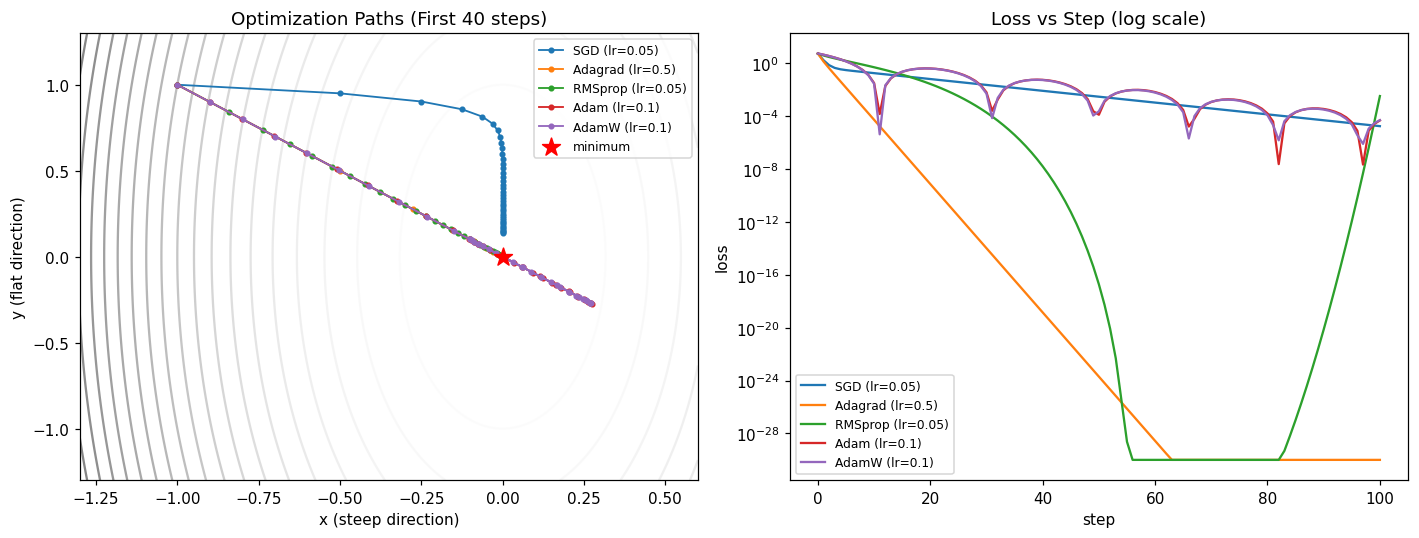

In [34]:
runs = {
    "SGD (lr=0.05)":       sgd(grad_fn, theta0, lr=0.05, steps=100),
    "Adagrad (lr=0.5)":    adagrad(grad_fn, theta0, lr=0.5, steps=100),
    "RMSprop (lr=0.05)":   rmsprop(grad_fn, theta0, lr=0.05, steps=100),
    "Adam (lr=0.1)":       adam(grad_fn, theta0, lr=0.1, steps=100),
    "AdamW (lr=0.1)":      adamw(grad_fn, theta0, lr=0.1, steps=100, wd=0.01),
}

print(f"{'Optimizer':<20} | {'final theta':<24} | final loss")
for name, h in runs.items():
    print(f"{name:<20} | {str(h[-1]):<24} | {loss_fn(h[-1]):.3e}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (a) Contour + paths
xs, ys = np.meshgrid(np.linspace(-1.3, 0.6, 200), np.linspace(-1.3, 1.3, 200))
zs = 5 * xs**2 + 0.5 * ys**2
ax[0].contour(xs, ys, zs, levels=20, cmap="Greys", alpha=0.5)
for name, h in runs.items():
    ax[0].plot(h[:40, 0], h[:40, 1], marker="o", ms=3, lw=1.2, label=name)   # first 40 steps
ax[0].scatter([0], [0], c="red", marker="*", s=150, zorder=5, label="minimum")
ax[0].set_title("Optimization Paths (First 40 steps)")
ax[0].set_xlabel("x (steep direction)"); ax[0].set_ylabel("y (flat direction)")
ax[0].legend(fontsize=8)

# (b) Loss curves (log scale)
for name, h in runs.items():
    losses = [loss_fn(p) for p in h]
    ax[1].plot(np.maximum(losses, 1e-30), label=name)
ax[1].set_yscale("log")
ax[1].set_title("Loss vs Step (log scale)")
ax[1].set_xlabel("step"); ax[1].set_ylabel("loss")
ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### Key Observations from the Plots & Table
- **SGD (blue):** Resolves the steep x-direction quickly, but drags along the flat y-direction because it uses a single global learning rate.
- **Adagrad / RMSprop / Adam / AdamW:** Both dimensions progress at an **equal rate** (which is why their trajectory is a straight diagonal line). This is the power of adaptive step-sizing.
- **Jitter near the minimum:** Since Adam and RMSprop adjust their step size to stay roughly proportional to `η` (as `g/√v` is around 1), they tend to overshoot the minimum and oscillate around it (as seen in the fluctuating loss curve for Adam).
- **RMSprop's bounce:** The loss drops close to 0 but bounces back up. When the gradient becomes extremely small, `E` also becomes small, causing the step size `g/√E` to stay relatively large and nudge the weights away from the minimum. This is a known trait of adaptive methods.
- **Why Adagrad performs best here:** Its learning rate `η/√G` continuously decays, allowing it to settle smoothly at the minimum of this toy problem. However, in noisy real-world scenarios, this continuous decay hinders learning over long runs.
- **SGD vs Adam on this problem:** SGD achieved a better final loss (1.75e-5) than Adam (4.7e-5) simply because this is a **deterministic** problem with no noise and the learning rate for SGD was manually tuned to perfection.
- **The True Advantage of Adaptive Optimizers:** They make the choice of `η` much more robust and easier to tune, as shown in the next cell.

### Bonus: Sensitivity to Learning Rates

In this loss bowl, the gradient in the x-direction is `10x`. For plain Gradient Descent to remain stable, the condition is `lr < 0.2`. Any value higher than this causes SGD to **diverge**. Let's compare how Adam handles higher learning rates:

In [35]:
print(f"{'lr':>5} | {'SGD final loss (50 steps)':>26} | {'Adam final loss (50 steps)':>27}")
with np.errstate(all="ignore"):
    for lr in [0.05, 0.15, 0.25, 0.5]:
        l_sgd  = loss_fn(sgd(grad_fn, theta0, lr=lr, steps=50)[-1])
        l_adam = loss_fn(adam(grad_fn, theta0, lr=lr, steps=50)[-1])
        print(f"{lr:5.2f} | {l_sgd:26.3e} | {l_adam:27.3e}")
print("\nSGD diverges at lr=0.25 and above (loss reaches 1e+18). Adam stays within a stable range across all these learning rates.")

   lr |  SGD final loss (50 steps) |  Adam final loss (50 steps)
 0.05 |                  2.960e-03 |                   7.893e-03
 0.15 |                  4.374e-08 |                   2.046e-03
 0.25 |                  2.033e+18 |                   6.108e-03
 0.50 |                  8.035e+60 |                   1.650e-02

SGD diverges at lr=0.25 and above (loss reaches 1e+18). Adam stays within a stable range across all these learning rates.


## 📌 Cheat Sheet (For quick revision)

| Optimizer | Diary Tracking | Update Step | Drawback | Fix |
|---|---|---|---|---|
| **Adagrad** | `G = G + g²` | `θ −= η·g/(√G+ε)` | `G` only increases → learning rate drops to zero | RMSprop |
| **RMSprop** | `E = βE + (1−β)g²` | `θ −= η·g/(√E+ε)` | Lacks directional smoothing, has initial startup bias | Adam |
| **Adam** | `m` (avg gradient), `v` (avg squared gradient) | `θ −= η·m̂/(√v̂+ε)` | L2 regularization gets distorted by adaptive scaling | AdamW |
| **AdamW** | Same as Adam | `θ −= η·(m̂/(√v̂+ε) + λθ)` | None (current industry standard) | LR schedule (Day 091) |

**Adam default hyperparameters:** `lr=1e-3, β₁=0.9, β₂=0.999, ε=1e-8`. In AdamW, `weight_decay` is typically initialized at `0.01`.

### Moving to PyTorch (Day 095+)
| Our Implementation (NumPy) | PyTorch Equivalent |
|---|---|
| `adagrad(...)` | `torch.optim.Adagrad` |
| `rmsprop(...)` | `torch.optim.RMSprop` |
| `adam(...)` | `torch.optim.Adam` |
| `adamw(...)` | `torch.optim.AdamW` |

⚠️ In PyTorch, using `Adam(weight_decay=...)` applies the **older, distorted L2 regularization**. If you want decoupled weight decay, make sure to use `AdamW` instead.

## 🎤 Interview Questions (Try answering these first before checking the short answers)

| # | Question | Short Answer |
|---|---|---|
| 1 | Why does Adagrad's learning rate diminish over time? | `G` accumulates continuously, meaning the denominator in `η/√G` grows infinitely and shrinks the step size to zero. |
| 2 | How does RMSprop resolve Adagrad's diminishing learning rate? | It swaps the sum for an exponential moving average, allowing the optimizer to discount older histories. |
| 3 | What are `m` and `v` in Adam? | `m` tracks the first moment (momentum/direction), and `v` tracks the second moment (uncentered variance/step scaling). |
| 4 | Why is bias correction necessary? | Since `m` and `v` start at 0, their early steps are heavily biased towards 0. Bias correction scales them up during early iterations. |
| 5 | What is the main difference between Adam and AdamW? | Adam scales the weight decay penalty by the inverse of the historical gradient magnitude, whereas AdamW applies the decay directly to the weights. |

## ✍️ Today's Homework

1. **Manual Trace:** Given `g = [2, 0.5]` and `η = 0.1`, manually compute 3 steps of Adagrad on paper, then write code to verify your calculations.
2. **Tuning β:** Modify `beta` in RMSprop using values of `0.5`, `0.9`, and `0.99`. Compare which one is fast, slow, or unstable and write down your findings in markdown.
3. **Disable Bias Correction:** Create a copy of the `adam()` function and remove the `m_hat` and `v_hat` corrections (using `m` and `v` directly). Compare the trajectories of the first 5 steps.
4. **Reflective Summary (3-4 lines):** Write down in your own words: *"Why is decoupled weight decay in AdamW superior to standard L2 regularization in Adam?"*